In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os



plt.rcParams.update({
    "font.size": 11,            # base font size (tick labels)
    "axes.labelsize": 13,       # axis labels
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
})

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_device', jax.devices('cpu')[0])

# Import your optimization and plotting utilities
from optimization_core import (
    scaled_spdc_jsa_vectorized,
    load_results,
    tensor_knapsack_bound_5D,
)

In [ ]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------
# # Sweep parameters
n_steps=30 # Number of steps in the sweep
# taup=jnp.linspace(-0.49, 0.99 , n_steps) #b is analogous to the correlation coefficients in the correlation matrix

#Dispersion parameters
ldelk01=0 # Phase mismatch at the central frequencies
tau11=0  # Group-velocity matching
# taup1=1 # \beta_P << \beta_F -->\beta_P negligible in comparison to \beta_F
taup1 = jnp.linspace(
    0, 9, n_steps
)  # We can also sweep over taup1, which is the parameter that controls the pump bandwidth. This allows us to explore different regimes of pump bandwidth in relation to the phase-matching function.
taup = taup1[taup1 < 7.2]
tauf1=1.5 # \beta_F >> \beta_P
T0=tauf1/jnp.sqrt(jnp.pi) # Pump bandwidth
T01=0 # Ultrafast pump approximation

# Geometrical parameters
n_res=10 # Number of points inside the bandwidth of the phase-matching function in the frequency grid nxnxn
d=5 # Dimensionality of the problem

# Spectral resolution
sigmapm=jnp.sqrt(jnp.pi)/tauf1 # Approximate HWHM of the phase-matching function, measured in terms of the sinc's main lobe width
delw=sigmapm/n_res # The spectral resolution is defined such that a minimum of n discrete points are sampled within each frequency vector over the bandwidth of the phase-matching function, regardless of the specific width of the evaluation function.

#Spectral window
domg=2.5*sigmapm # We set the half-width of the frequency window wide enough to sample correctly both the jsa and reduced density matrix
omf=jnp.arange(-domg,domg,delw)
n=omf.size
print(n) # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage. 

# Create N‑dimensional meshgrid 
grid = jnp.meshgrid(*([omf]*d), indexing="ij")

50


In [3]:
# sigma_list=[]
# eta_list=[]
# upper_bound_list=[]

# for i,taup_value in enumerate(taup):
#     # ---------------------------------------------------------
#     # 1. Export data
#     # ---------------------------------------------------------
#     filename = f"eigen_eval_results_hopdc_{d}D_20260621_taup_{taup_value:.2f}_tauf_{tauf1:.2f}.pkl"
#     if os.path.exists('results_data/'+filename):
#         df,_,_=load_results(filename)
#         f_pen = df["optim_lo"]
#         fun_pen = df["eta"]

#         # ---------------------------------------------------------
#         # 2. Build JSA grid and initial mode
#         # ---------------------------------------------------------
#         print("Building JSA grid...")
#         jsa = scaled_spdc_jsa_vectorized(ldelk0=ldelk01, tau1=tau11, taup=taup_value, tauf=tauf1, T0=T01) # Returns a callable function that evaluates the JSA on a point or a grid.
#         jsa_data = jsa(*grid) # Evaluate the JSA on the grid. This is the most memory intensive step, as it creates a large tensor of size (n,n,n) in this case. Always check the size of the grid and the resulting tensor to avoid memory issues.
#         jsa_data/=jnp.linalg.norm(jsa_data) # Normalize the JSA data. 
#         jsa_flat=jnp.reshape(jsa_data,(n,n**(d-1)))
#         u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

#         bound, tau_opt,sigma,mu,v_caps = tensor_knapsack_bound_5D(jsa_data)

#         # Compute bounds
#         upper_bound = bound
#         sigma_1 = s[0]

#         # Print results
#         print(rf"Actual $\eta$: {fun_pen:.4f}")
#         print(f"Actual sigma_1: {sigma_1:.4f}")
#         print(f"Upper bound: {jnp.abs(upper_bound):.4f}")
#         sigma_list.append(sigma_1)
#         eta_list.append(fun_pen)
#         upper_bound_list.append(upper_bound)
      

In [4]:
# r_values = (taup**2/tauf1**2)
# sigma = jnp.array(sigma_list)
# actual_value = jnp.array(eta_list)
# upper_bound = jnp.array(upper_bound_list)

# np.savez(f"knapsack_bounds_hopdc_{d}D.npz",
#          taup=taup,
#          tauf=tauf1,
#          sigma=sigma,
#          actual_value=actual_value,
#          upper_bound=upper_bound)

In [5]:
data = np.load(f"knapsack_bounds_hopdc_{d}D.npz")

# Extract arrays
taup = data["taup"]
tauf = data["tauf"]
sigma= data["sigma"]
actual_value = data["actual_value"]
upper_bound = data["upper_bound"]

r_values = taup**2 / tauf**2

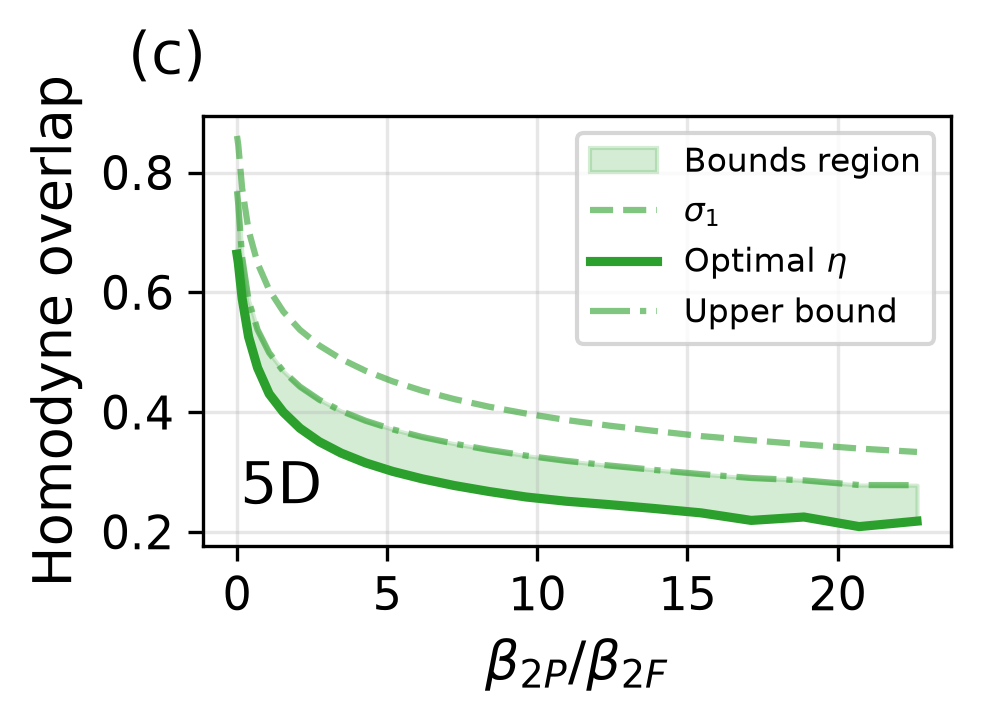

In [6]:
# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:green"   # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region"
)

# --- Sigma 1 ---
ax.plot(
    r_values,
    sigma,
    color=base_color,
    alpha=0.6,
    linestyle="--",
    label=r"$\sigma_1$"
)

# --- Actual value ---

ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$"
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound"
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(0.05, 0.10, f"{d}D", transform=ax.transAxes, fontsize=14)

# Panel label (e.g., "(a)")
ax.text(
    -0.10, 1.1, "(c)",
    transform=ax.transAxes,
    fontsize=14
)

ax.set_xlabel(r"$\beta_{2P}/\beta_{2F}$")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"knapsack_bound_hopdc_{d}D_plot_sigma.pdf", dpi=300, bbox_inches="tight")
plt.show()


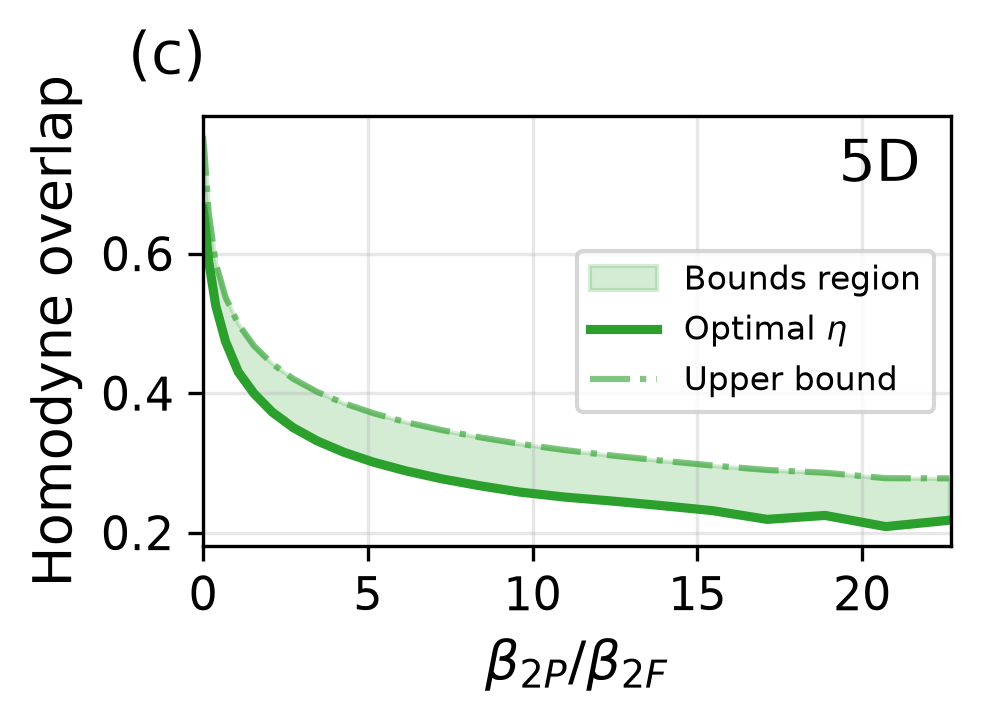

In [7]:
# plt.figure(figsize=(7,5))
fig, ax = plt.subplots(figsize=(3.4, 2.6))

base_color = "tab:green"   # choose any: "tab:red", "tab:green", etc.

# --- Shaded region between lower and upper ---
ax.fill_between(
    r_values,
    actual_value,
    upper_bound,
    color=base_color,
    alpha=0.2,
    label="Bounds region"
)



# --- Actual value ---
ax.plot(
    r_values,
    actual_value,
    color=base_color,
    alpha=1.0,
    linewidth=2.2,
    label=r"Optimal $\eta$"
)

# --- Upper bound ---
ax.plot(
    r_values,
    upper_bound,
    color=base_color,
    alpha=0.6,
    linestyle="-.",
    label=r"Upper bound"
)

# Internal tag for dimensionality (e.g., "3D")
ax.text(
    0.85, 0.85, "5D",
    transform=ax.transAxes,
    fontsize=14
)

# Panel label (e.g., "(a)")
ax.text(
    -0.10, 1.1, "(c)",
    transform=ax.transAxes,
    fontsize=14
)

ax.set_xlabel(r"$\beta_{2P}/\beta_{2F}$")
ax.set_ylabel("Homodyne overlap")
ax.grid(True, alpha=0.3)
plt.xlim([0, 22.7])
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"knapsack_bound_hopdc_{d}D_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
